# **생활습관 데이터를 활용한 Z세대 정신건강 요인 분석 및 정신건강 위험 예측**

# **1. EDA를 위한 전처리**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/2026 여름방학 비교과/genz_mental_wellness_synthetic_dataset.csv')
df

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,18,Female,Pakistan,Student,3.17,8.06,2.12,0.92,Entertainment,0.73,...,4.00,5.11,5.45,6.72,2.89,6.21,4.78,6.99,3.83,High
9996,24,Male,Pakistan,Both,3.80,7.79,1.10,0.04,Entertainment,3.40,...,3.79,2.51,2.76,6.30,4.05,6.93,5.75,5.28,4.99,Medium
9997,23,Female,Australia,Both,2.35,5.13,2.11,3.20,Gaming,4.26,...,5.16,3.27,3.75,7.40,3.26,6.83,4.98,3.01,5.28,Medium
9998,26,Female,USA,Student,4.53,6.59,4.27,0.00,Lifestyle,3.19,...,7.41,5.37,3.30,6.00,4.18,7.15,6.18,5.92,4.90,Medium


In [ ]:
# 행, 열 개수
print(df.shape)
print()

# 컬럼명
print(df.columns)
print()

# 데이터 타입
df.info()
print()

# 기초통계량 (기술통계 확인(평균, 표준편차, 최소최대값))
df.describe()
print()

# 범주형 변수 통계
df.describe(include='object')

(10000, 22)

Index(['Age', 'Gender', 'Country', 'Student_Working_Status',
       'Daily_Social_Media_Hours', 'Screen_Time_Hours',
       'Night_Scrolling_Frequency', 'Online_Gaming_Hours',
       'Content_Type_Preference', 'Exercise_Frequency_per_Week',
       'Daily_Sleep_Hours', 'Caffeine_Intake_Cups', 'Study_Work_Hours_per_Day',
       'Overthinking_Score', 'Anxiety_Score', 'Mood_Stability_Score',
       'Social_Comparison_Index', 'Sleep_Quality_Score', 'Motivation_Level',
       'Emotional_Fatigue_Score', 'Wellbeing_Index', 'Burnout_Risk'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Country                      10000 non-null  object 
 3   Student_Working_Status 

,Gender,Country,Student_Working_Status,Content_Type_Preference,Burnout_Risk
count,10000,10000,10000,10000,10000
unique,3,6,3,5,3
top,Male,Pakistan,Student,Gaming,High
freq,4547,1804,5971,2051,5388


In [ ]:
df["Burnout_Risk"].value_counts()

,count
Burnout_Risk,
High,5388
Medium,4548
Low,64


In [ ]:
# 각 Score 변수의 범위

score_cols = [
    'Sleep_Quality_Score',
    'Overthinking_Score',
    'Anxiety_Score',
    'Mood_Stability_Score',
    'Social_Comparison_Index',
    'Motivation_Level',
    'Emotional_Fatigue_Score',
    'Wellbeing_Index'
]

df[score_cols].agg(['min', 'max']).T

,min,max
Sleep_Quality_Score,1.02,10.00
Overthinking_Score,1.00,9.51
Anxiety_Score,1.00,9.69
Mood_Stability_Score,1.00,10.00
Social_Comparison_Index,1.00,9.42
Motivation_Level,1.00,10.00
Emotional_Fatigue_Score,1.00,10.00
Wellbeing_Index,1.00,8.86


ㄴ> 모든 Score 및 Index 변수의 범위를 확인한 결과, 모두 약 1~10점 척도로 구성되어 있었다.

 Mood_Stability_Score, Motivation_Level, Wellbeing_Index, Sleep_Quality_Score

 --> 점수 높을수록 긍정적인 상태

 Anxiety_Score, Overthinking_Score, Social_Comparison_Index, Emotional_Fatigue_Score

 --> 점수 높을수록 부정적인 상태

In [ ]:
columns_df = pd.DataFrame(df.columns, columns=["Column"])

print(columns_df)

                         Column
0                           Age
1                        Gender
2                       Country
3        Student_Working_Status
4      Daily_Social_Media_Hours
5             Screen_Time_Hours
6     Night_Scrolling_Frequency
7           Online_Gaming_Hours
8       Content_Type_Preference
9   Exercise_Frequency_per_Week
10            Daily_Sleep_Hours
11         Caffeine_Intake_Cups
12     Study_Work_Hours_per_Day
13           Overthinking_Score
14                Anxiety_Score
15         Mood_Stability_Score
16      Social_Comparison_Index
17          Sleep_Quality_Score
18             Motivation_Level
19      Emotional_Fatigue_Score
20              Wellbeing_Index
21                 Burnout_Risk


In [ ]:
# 결측치 개수
df.isnull().sum()

# 결측치 비율(%)
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

## --> 결측치 X

,0
Age,0.0
Gender,0.0
Country,0.0
Student_Working_Status,0.0
Daily_Social_Media_Hours,0.0
Screen_Time_Hours,0.0
Night_Scrolling_Frequency,0.0
Online_Gaming_Hours,0.0
Content_Type_Preference,0.0
Exercise_Frequency_per_Week,0.0


In [ ]:
# 중복 데이터 확인
df.duplicated().sum()

##--> 중복 데이터 X

np.int64(0)

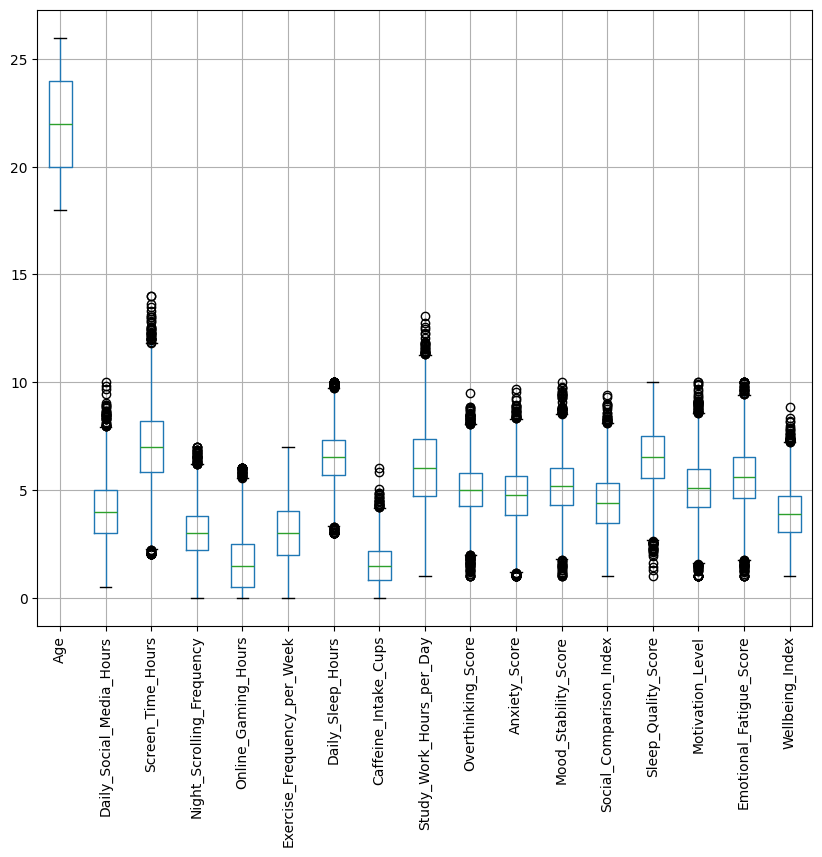

In [ ]:
# 이상치 확인

import matplotlib.pyplot as plt

df.boxplot(figsize=(10,8))
plt.xticks(rotation=90)
plt.show()

ㄴ> 일부 변수에서 이상치 확인.

생활습관 및 정신건강 데이터의 특성상 극단적인 값도 실제 위험군을 나타낼 수 있음

--> 제거X

**최종 사용 변수**

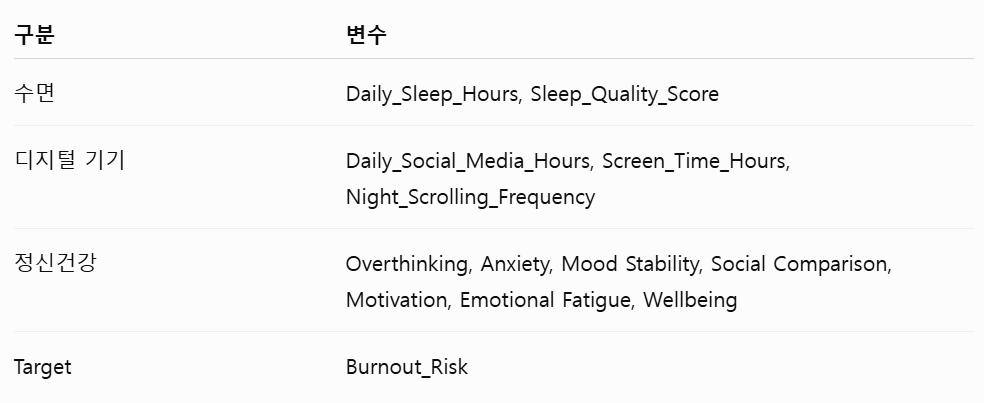

# **2. 생활 습관 EDA**

## **2-1. 수면 EDA**

In [ ]:
sleep_cols = [
    'Daily_Sleep_Hours',
    'Sleep_Quality_Score',
]

mental_cols = [
    'Overthinking_Score',
    'Anxiety_Score',
    'Mood_Stability_Score',
    'Social_Comparison_Index',
    'Motivation_Level',
    'Emotional_Fatigue_Score',
    'Wellbeing_Index'
]

In [ ]:
# 1. 기술통계: 전체적 분포 확인

sleep_mental = sleep_cols + mental_cols

df[sleep_mental].describe().round(2)

,Daily_Sleep_Hours,Sleep_Quality_Score,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,6.51,6.51,5.00,4.75,5.16,4.40,5.09,5.58,3.87
std,1.19,1.43,1.14,1.31,1.26,1.34,1.31,1.42,1.24
min,3.00,1.02,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,5.71,5.55,4.24,3.84,4.31,3.47,4.20,4.62,3.02
50%,6.52,6.53,5.00,4.74,5.17,4.40,5.08,5.58,3.87
75%,7.32,7.49,5.76,5.63,6.00,5.32,5.95,6.54,4.70
max,10.00,10.00,9.51,9.69,10.00,9.42,10.00,10.00,8.86


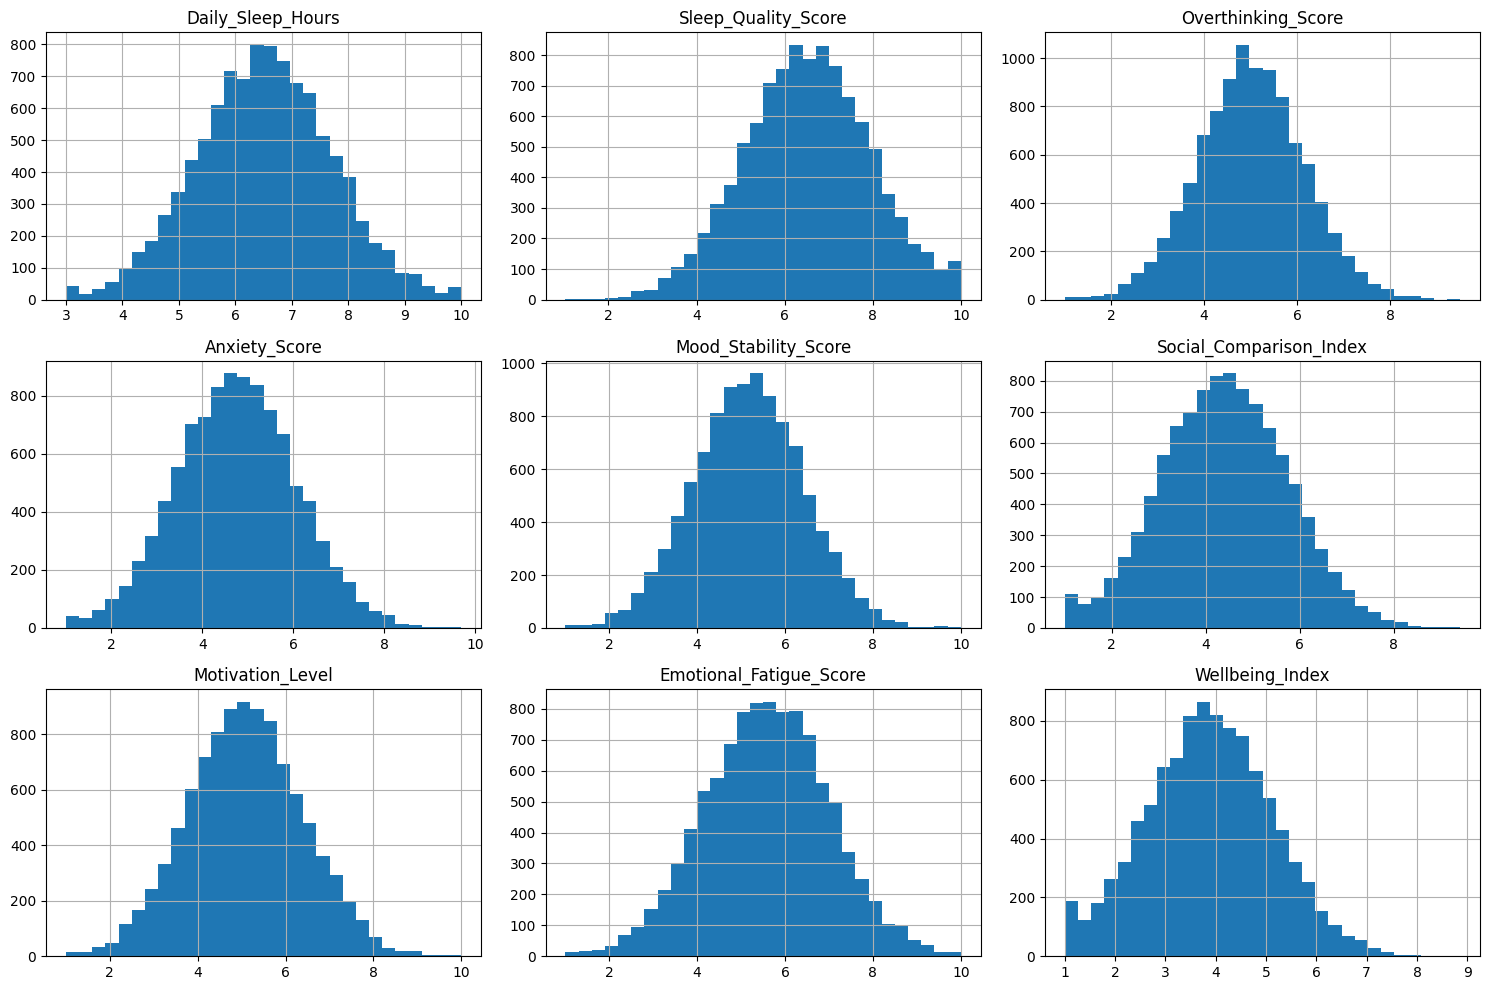

In [ ]:
import matplotlib.pyplot as plt

df[sleep_mental].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

전체 변수의 분포를 확인한 결과, 대부분의 변수는 종 모양의 정규분포에 가까운 형태를 보였다.



수면시간(Daily_Sleep_Hours)과 수면의 질(Sleep_Quality_Score)은 중간 수준(약 6-7시간, 6~7점)에 데이터가 집중되어 있었으며, 정신건강 관련 변수들도 평균 부근에 관측치가 많이 분포하였다.

또한 특정 값에 과도하게 치우친 분포는 나타나지 않아 이후 상관관계 분석 및 머신러닝 모델 적용에 적합한 데이터 분포를 보였다.

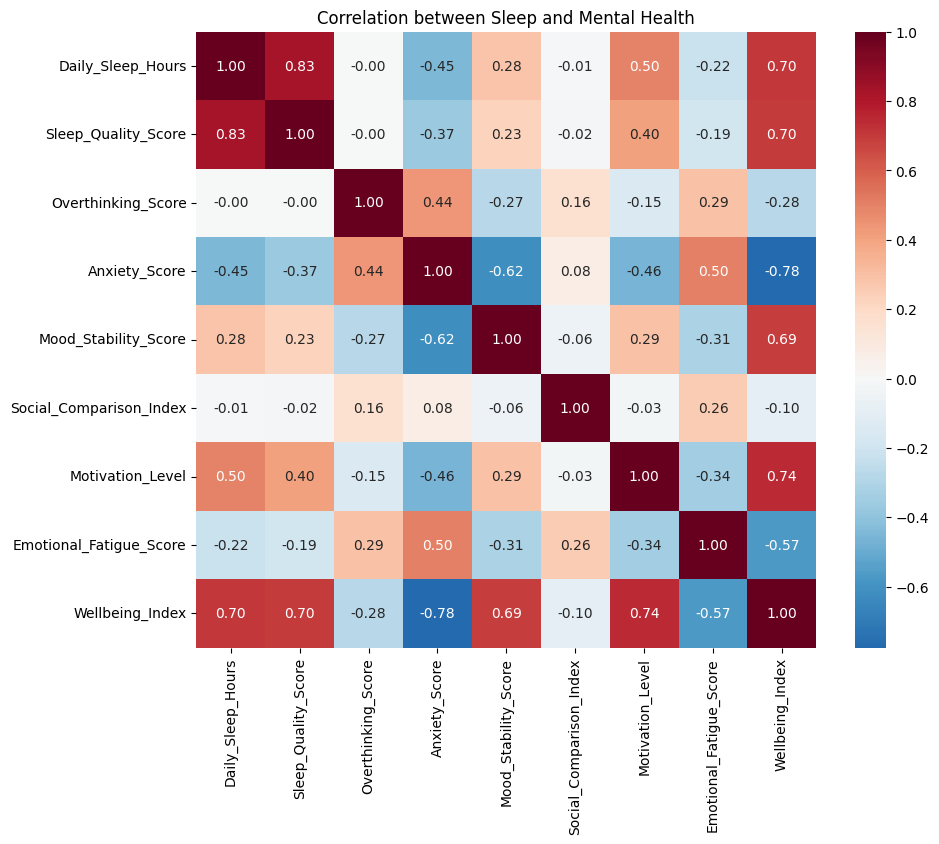

In [ ]:
#2. 상관관계 분석***

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df[sleep_mental].corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Correlation between Sleep and Mental Health")
plt.show()

Daily_Sleep_Hours와 Sleep_Quality_Score 두 변수 모두 Wellbeing_Index와 높은 양의 상관관계(r≈0.70)를 나타냈으며, Motivation_Level과도 양의 상관관계를 보였다.

반면 Anxiety_Score와는 음의 상관관계(r=-0.45, -0.37)를 보여 수면시간과 수면의 질이 높을수록 불안 수준이 낮아지는 경향을 확인할 수 있었다.

Emotional_Fatigue_Score와는 약한 음의 상관관계를 보였으며, Overthinking_Score와 Social_Comparison_Index는 수면 변수와 거의 상관관계가 없는 것으로 나타났다.

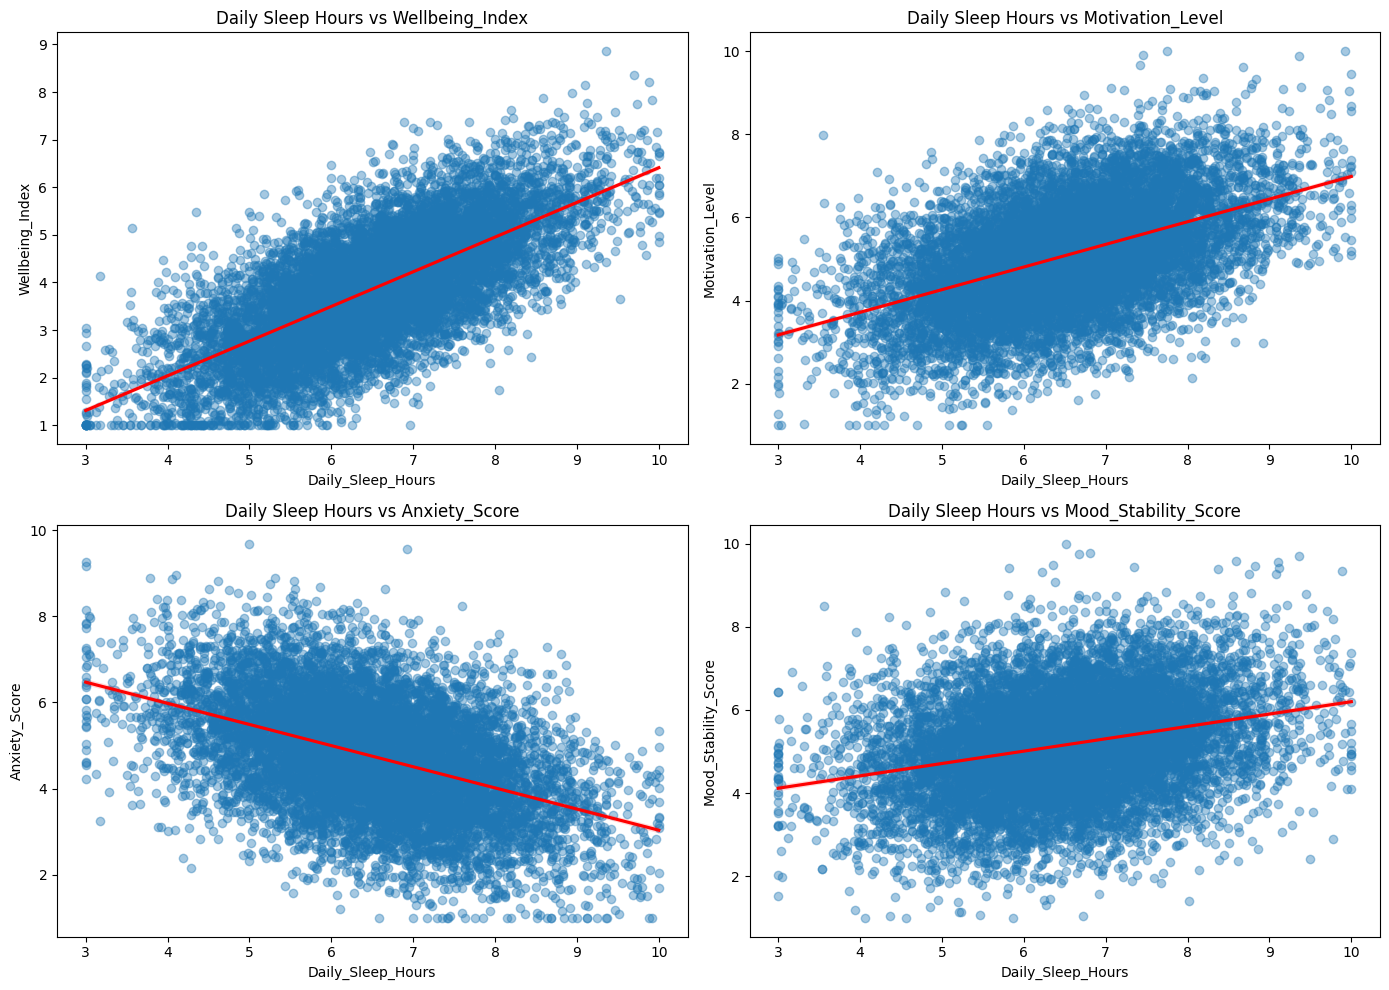

In [ ]:
# 3. 산점도 (Scatter)

# 수면 시간
import matplotlib.pyplot as plt
import seaborn as sns

important = [
    'Wellbeing_Index',
    'Motivation_Level',
    'Anxiety_Score',
    'Mood_Stability_Score'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), important):
    sns.regplot(
        data=df,
        x='Daily_Sleep_Hours',
        y=col,
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=ax
    )

    ax.set_title(f'Daily Sleep Hours vs {col}')

plt.tight_layout()
plt.show()

수면시간이 증가할수록 Wellbeing_Index와 Motivation_Level은 증가하는 경향

Anxiety_Score는 감소하는 경향

Emotional_Fatigue_Score는 완만한 감소 추세를 보여 수면시간과 약한 음의 관계가 있음을 확인

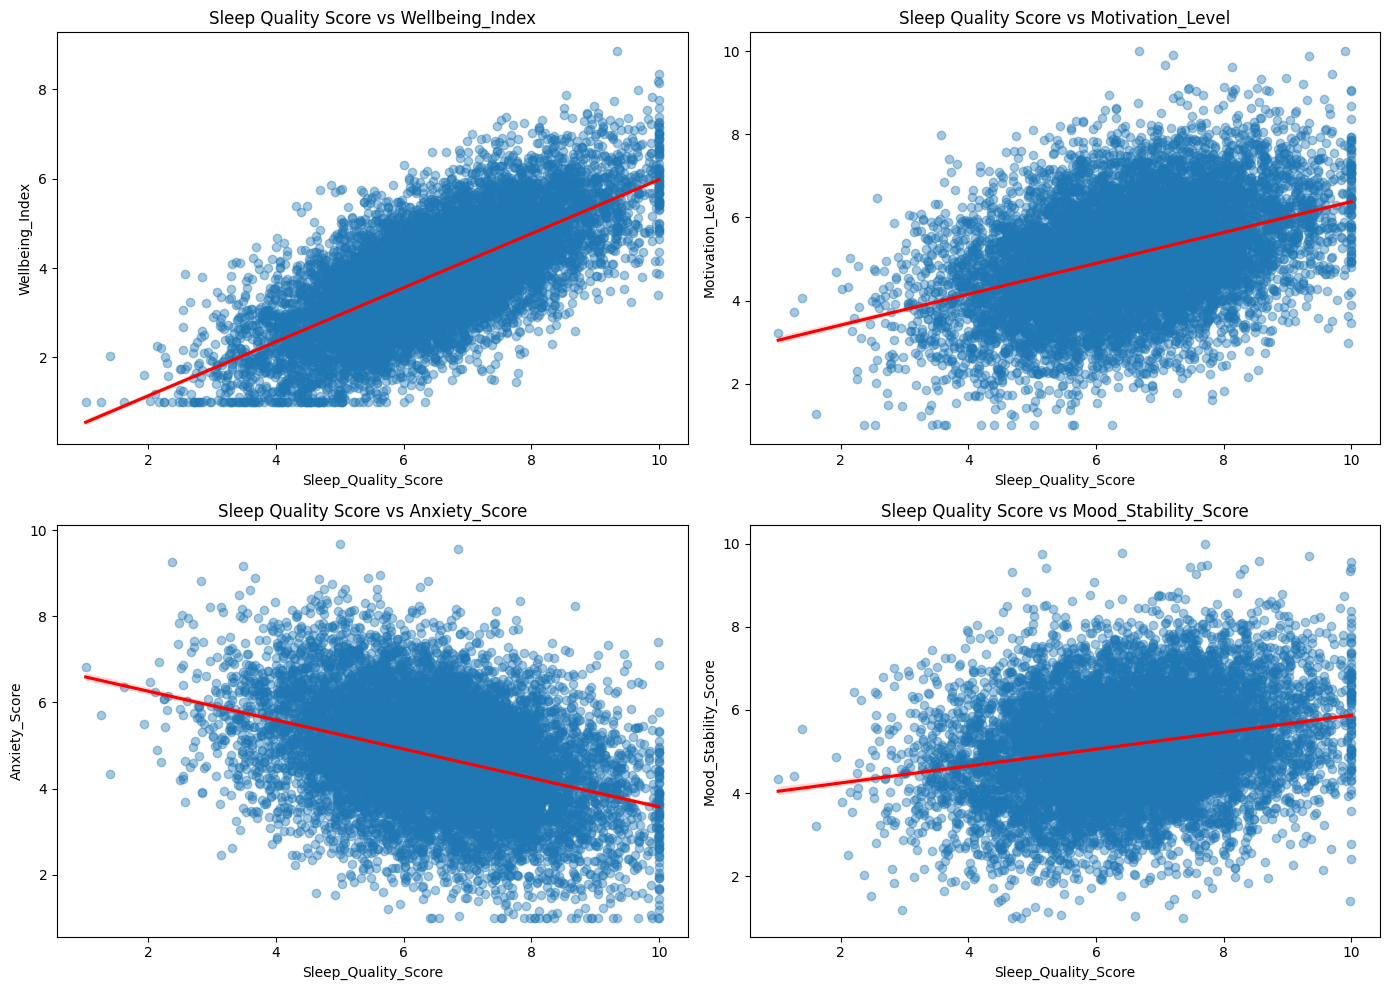

In [ ]:
# 수면의 질
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), important):
    sns.regplot(
        data=df,
        x='Sleep_Quality_Score',
        y=col,
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=ax
    )

    ax.set_title(f'Sleep Quality Score vs {col}')

plt.tight_layout()
plt.show()

수면의 질이 높을수록 Wellbeing_Index와 Motivation_Level은 증가하는 경향

Anxiety_Score는 감소하는 경향

Emotional_Fatigue_Score 역시 완만한 감소 추세를 보여 수면의 질이 높을수록 정서적 피로가 감소하는 경향을 확인

**수면 EDA 종합 결과**


수면시간과 수면의 질 모두 웰빙 지수 및 동기 수준과는 양의 관계를, 불안 수준 및 정서적 피로와는 음의 관계를 보였다.

특히 웰빙 지수와 불안 수준에서 비교적 뚜렷한 선형 관계가 확인되어, 충분하고 질 높은 수면이 정신건강 증진에 긍정적인 영향을 미칠 가능성을 확인

## **2-2. 디지털 기기 사용 습관 EDA**

In [ ]:
digital_cols = [
    'Daily_Social_Media_Hours',
    'Screen_Time_Hours',
    'Night_Scrolling_Frequency',
    'Online_Gaming_Hours'
]

In [ ]:
# 1. 기술 통계

digital_mental = digital_cols + mental_cols

df[digital_mental].describe().round(2)

,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4.01,7.02,2.99,1.61,5.00,4.75,5.16,4.40,5.09,5.58,3.87
std,1.48,1.79,1.20,1.30,1.14,1.31,1.26,1.34,1.31,1.42,1.24
min,0.50,2.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.01,5.81,2.19,0.47,4.24,3.84,4.31,3.47,4.20,4.62,3.02
50%,3.99,7.00,2.98,1.46,5.00,4.74,5.17,4.40,5.08,5.58,3.87
75%,4.98,8.21,3.79,2.50,5.76,5.63,6.00,5.32,5.95,6.54,4.70
max,10.00,14.00,7.00,6.00,9.51,9.69,10.00,9.42,10.00,10.00,8.86


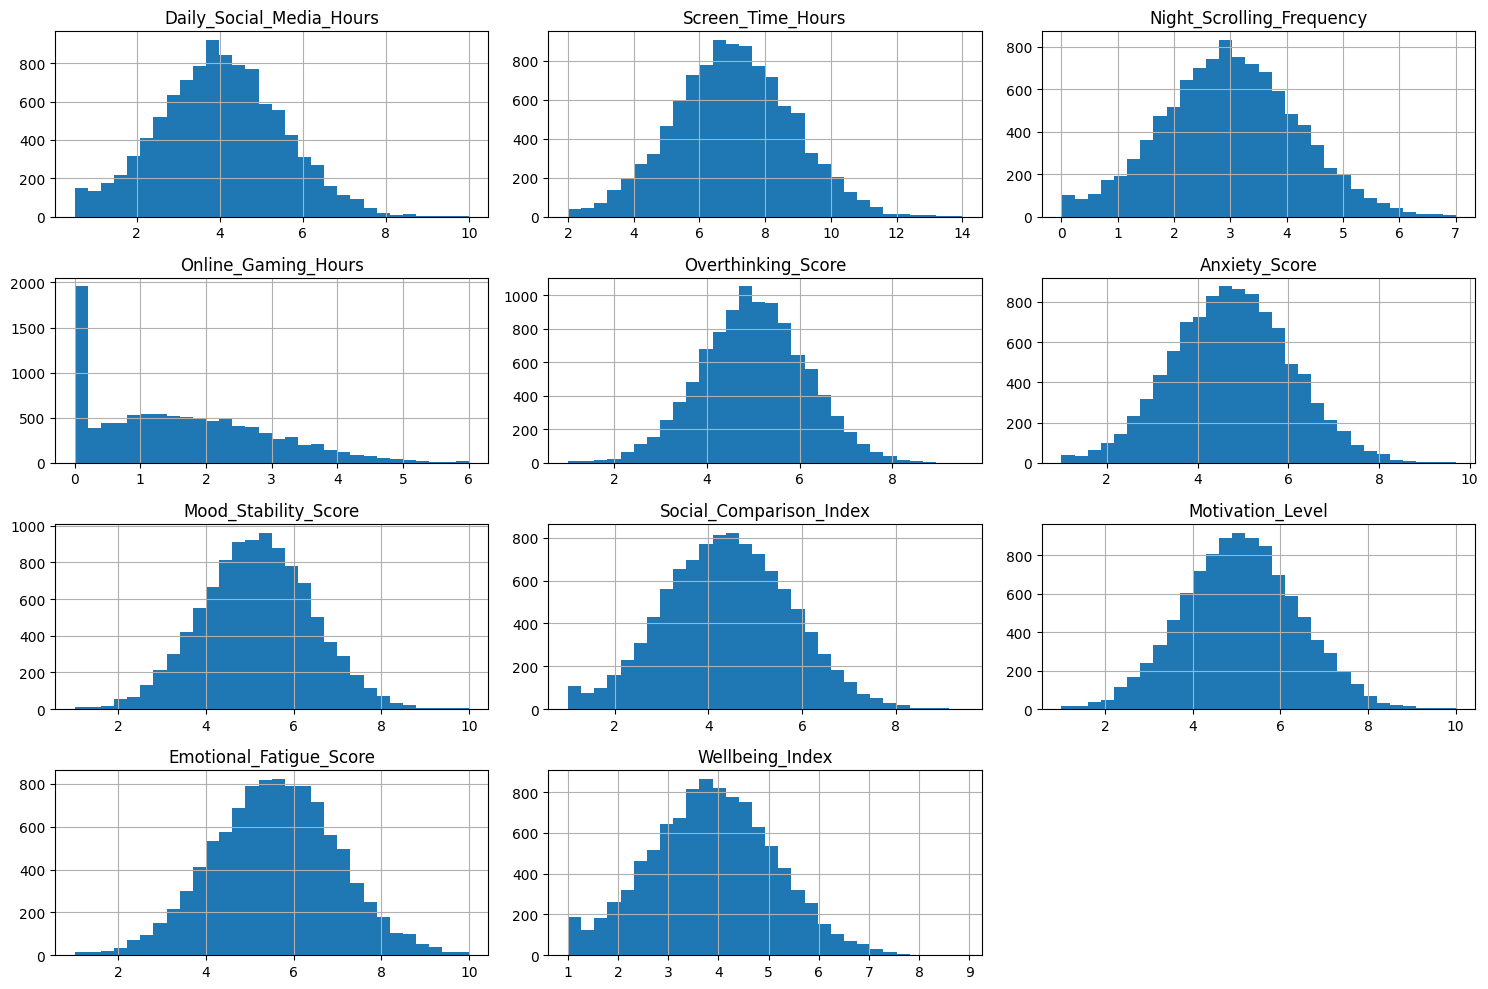

In [ ]:
# 2. 분포 확인

import matplotlib.pyplot as plt

df[digital_mental].hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

디지털 기기 사용 습관과 정신건강 관련 변수의 분포를 확인한 결과, 대부분의 변수는 정규분포에 가까운 형태를 보였으며 평균 부근에 데이터가 집중


 Daily_Social_Media_Hours는 약 3-5시간, Screen_Time_Hours는 약 6-8시간, Night_Scrolling_Frequency는 약 2-4회 구간에 관측치가 가장 많이 분포

 Online_Gaming_Hours는 0시간에 관측치가 많이 분포하여 게임을 하지 않는 응답자가 상당수 포함된 것으로 나타났다.

  또한 정신건강 관련 변수들 역시 특정 값에 과도하게 치우치지 않은 분포를 보여 이후 상관관계 분석 및 회귀분석을 수행하기에 적합한 데이터임을 확인

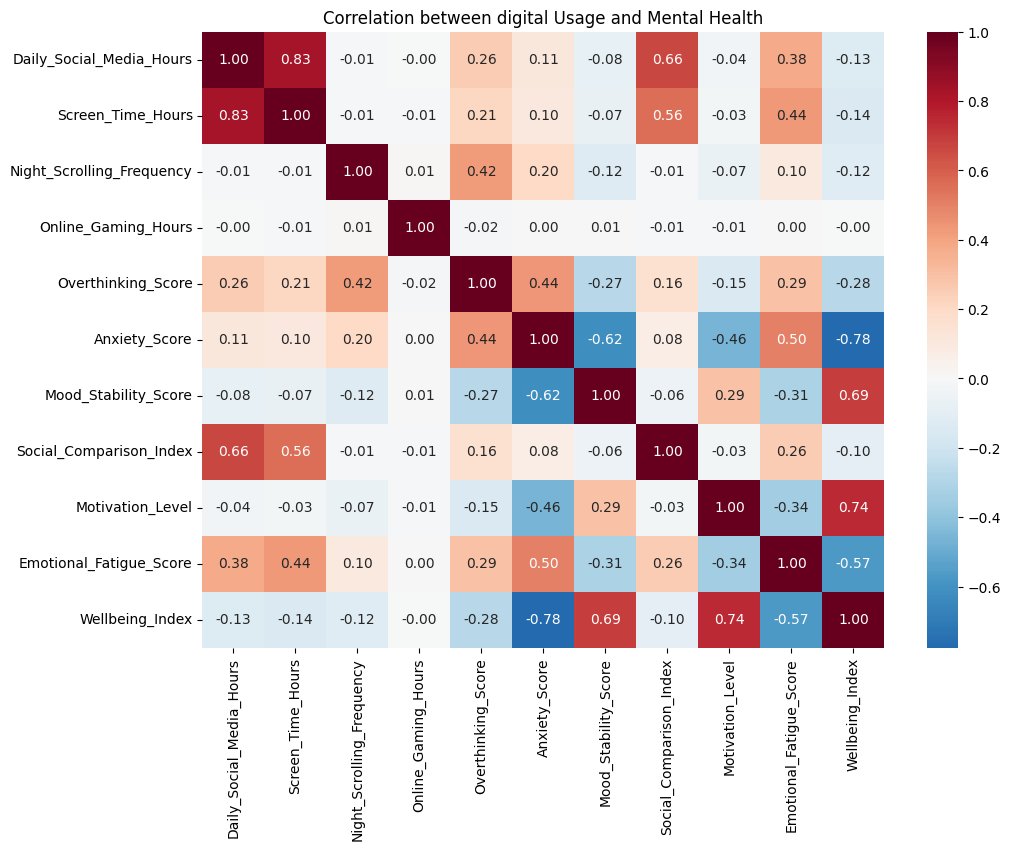

In [ ]:
# 3. 상관관계 분석

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,8))

sns.heatmap(
    df[digital_mental].corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Correlation between digital Usage and Mental Health")

plt.show()

Emotional_Fatigue_Score와 양의 상관관계를 나타내 디지털 기기 사용시간이 길수록 사회적 비교와 정서적 피로가 증가하는 경향을 확인.

 반면 Wellbeing_Index와는 약한 음의 상관관계를 보여 디지털 기기 사용시간이 증가할수록 웰빙 수준이 다소 감소하는 경향

 특히 Night_Scrolling_Frequency는 Overthinking_Score와 0.42의 양의 상관관계를 보여 야간 스크롤링이 많을수록 과도한 생각이 증가하는 경향을 확인

 반면 Online_Gaming_Hours는 대부분의 정신건강 변수와 상관계수가 0에 가까워 뚜렷한 선형 관계는 나타나지 X

**차별점**

수면 EDA에서는 **수면 ↔ 불안·웰빙**이 핵심

디지털 기기 사용 EDA에서는 **디지털 기기 사용 ↔ 사회적 비교·과생각·정서적 피로**가 핵심

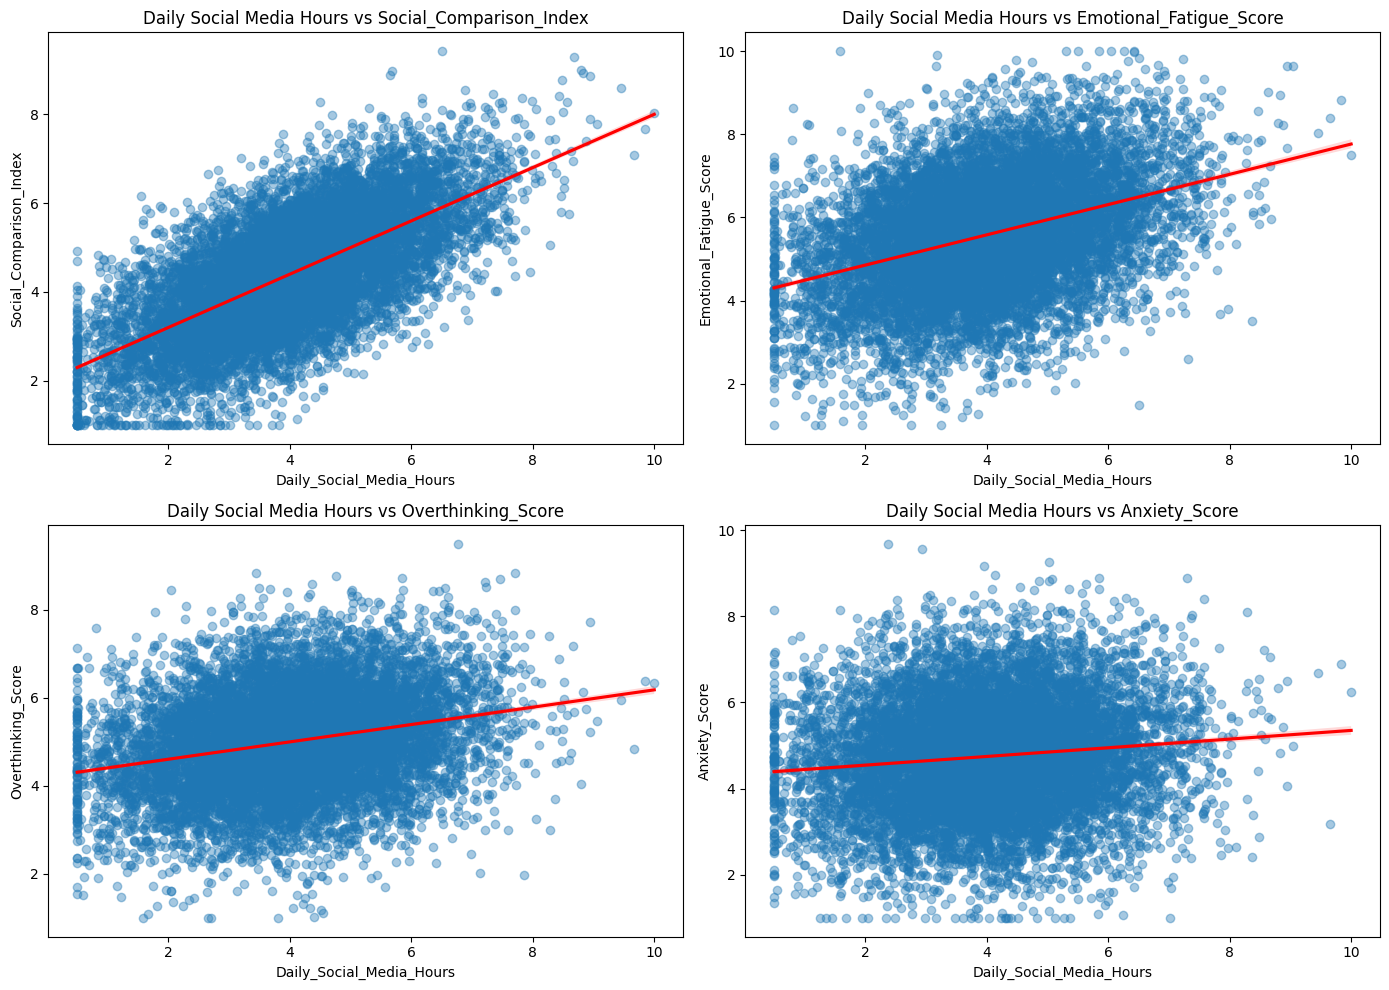

In [ ]:
# 4. 산점도

# SNS 이용시간
important = [
    'Social_Comparison_Index',
    'Emotional_Fatigue_Score',
    'Overthinking_Score',
    'Anxiety_Score'
]

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, col in zip(axes.flatten(), important):

    sns.regplot(
        data=df,
        x='Daily_Social_Media_Hours',
        y=col,
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=ax
    )

    ax.set_title(f'Daily Social Media Hours vs {col}')

plt.tight_layout()
plt.show()

SNS 이용시간이 증가할수록 Emotional_Fatigue_Score는 증가, Anxiety_Score는 완만한 증가,  Wellbeing_Index는 감소하는 경향

반면 Motivation_Level은 뚜렷한 변화 X

이를 통해 SNS 이용시간은 특히 정서적 피로와 웰빙 수준에 더 큰 영향을 미칠 가능성을 확인

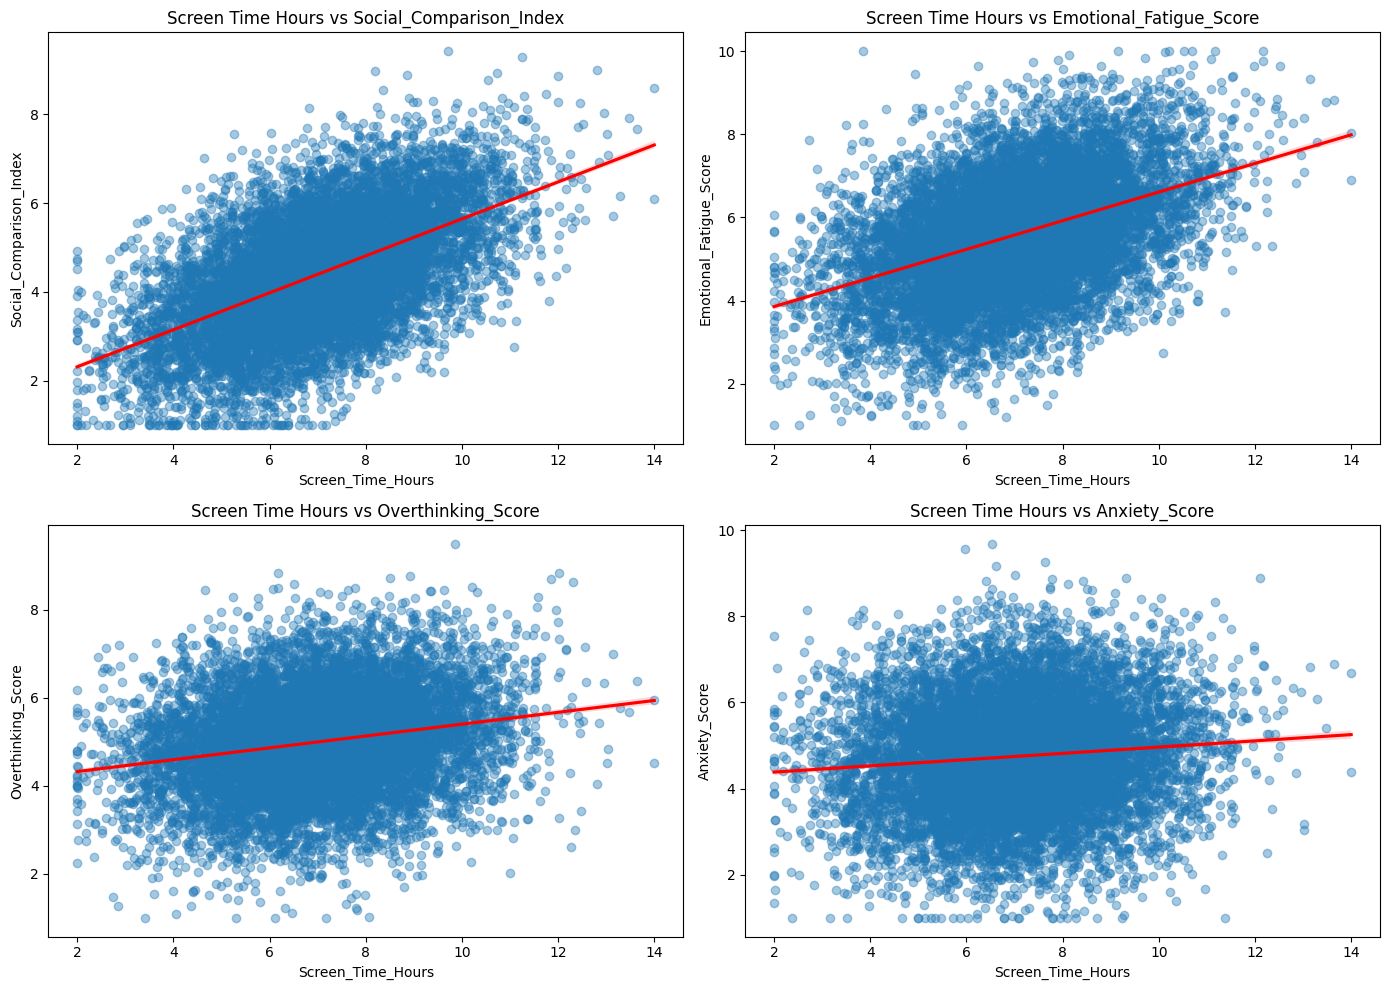

In [ ]:
# Screen Time
fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, col in zip(axes.flatten(), important):

    sns.regplot(
        data=df,
        x='Screen_Time_Hours',
        y=col,
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=ax
    )

    ax.set_title(f'Screen Time Hours vs {col}')

plt.tight_layout()
plt.show()

스크린 타임이 증가할수록 Emotional_Fatigue_Score는 증가, Anxiety_Score는 완만하게 증가, Wellbeing_Index는 감소하는 경향

또한 Motivation_Level은 뚜렷한 변화 X

이를 통해 장시간의 화면 사용은 정서적 피로를 높이고 웰빙 수준을 낮추는 것과 관련이 있음을 확인

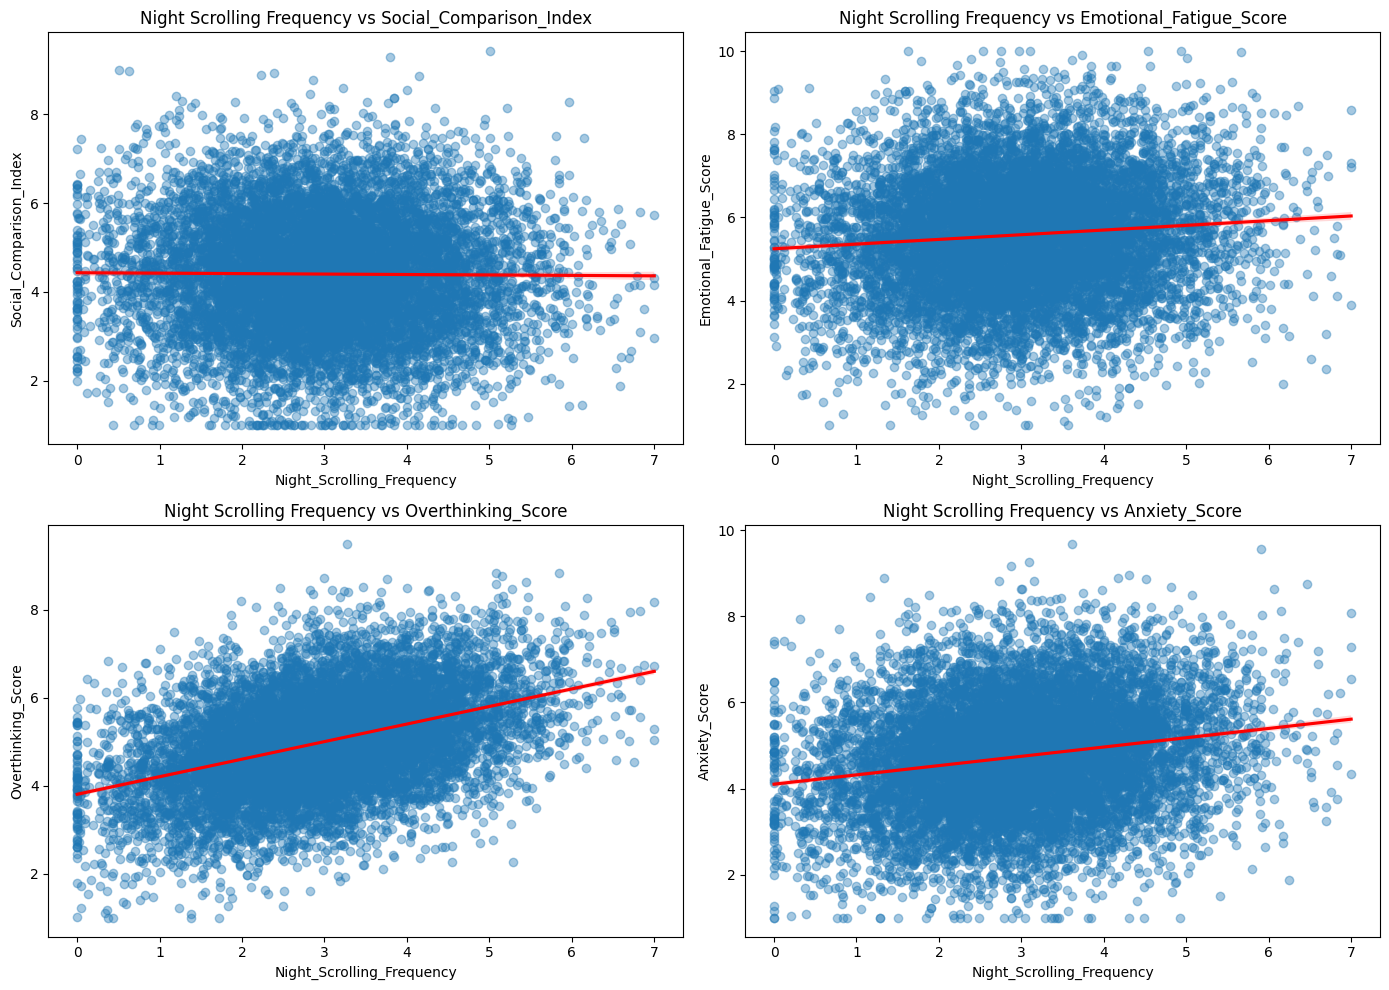

In [ ]:
# Night Scrolling

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, col in zip(axes.flatten(), important):

    sns.regplot(
        data=df,
        x='Night_Scrolling_Frequency',
        y=col,
        scatter_kws={'alpha':0.4},
        line_kws={'color':'red'},
        ax=ax
    )

    ax.set_title(f'Night Scrolling Frequency vs {col}')

plt.tight_layout()
plt.show()

야간 스크롤링이 증가할수록 Wellbeing_Index는 감소, Anxiety_Score와 Emotional_Fatigue_Score는 증가

다만 SNS 이용시간이나 화면 사용시간에 비해 회귀선의 기울기 완만 --> 관계의 강도는 상대적으로 약함.

또한 Motivation_Level은 뚜렷한 변화 X

이는 야간 스크롤링이 정신건강에 일정한 영향을 미치지만, 일부 변수에서는 영향력이 제한적일 수 있음을 시사

**디지털 기기 사용 EDA 종합 결과**

SNS 이용시간과 스크린 타임은 정서적 피로와 웰빙 수준에 상대적으로 큰 관련성을 보였으며,

야간 스크롤링은 과도한 생각(Overthinking) 및 불안 수준과의 관련성이 상대적으로 높게 나타났다.

**(참고) 수면과 디지털 기기 사용 EDA**

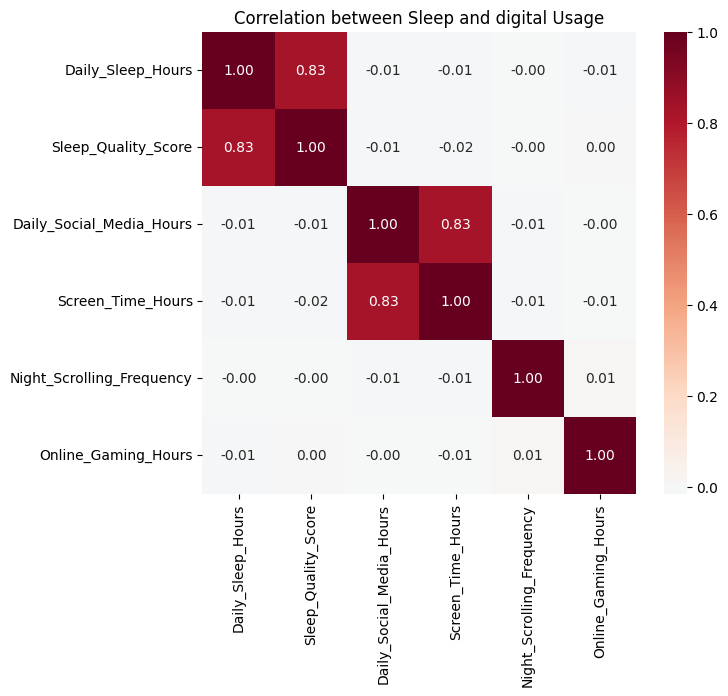

In [ ]:
lifestyle = sleep_cols + digital_cols

plt.figure(figsize=(7,6))

sns.heatmap(
    df[lifestyle].corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title("Correlation between Sleep and digital Usage")
plt.show()

수면 습관과 디지털 기기 사용 습관 사이에는 유의미한 상관관계 X

따라서 두 생활습관은 서로 직접적인 영향을 미치기보다는, 각각 정신건강 변수에 독립적으로 영향을 미치는 요인으로 분석하는 것이 적절하다고 판단함.

**(참고) 정신건강 변수 EDA**

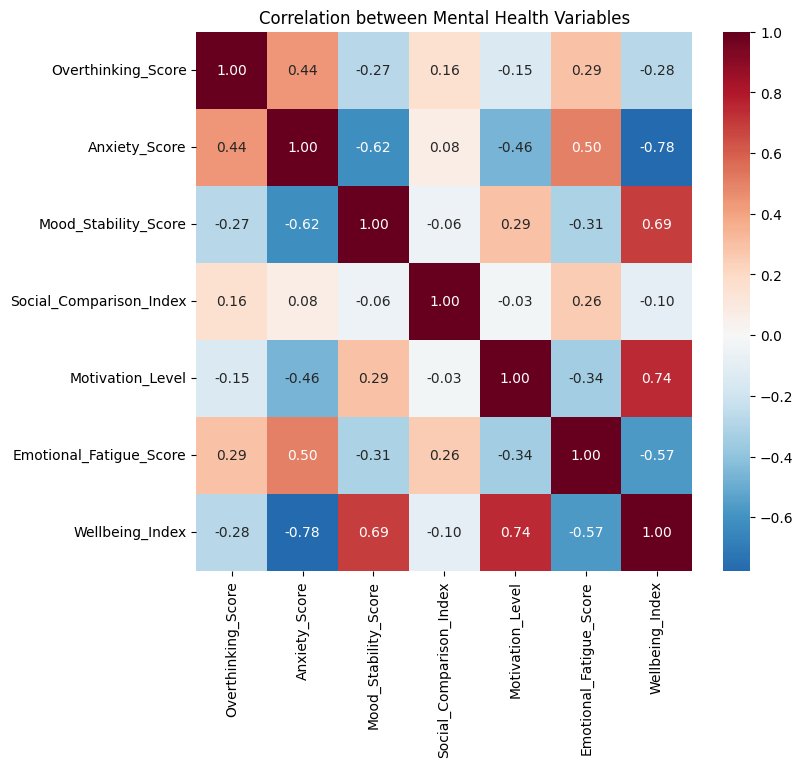

In [ ]:
plt.figure(figsize=(8,7))

sns.heatmap(
    df[mental_cols].corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt=".2f"
)

plt.title("Correlation between Mental Health Variables")

plt.show()

정신건강 변수 간 상관관계를 분석한 결과, Anxiety_Score는 Wellbeing_Index와 강한 음의 상관관계(r=-0.78)를, Mood_Stability_Score(r=0.69) 및 Motivation_Level(r=0.74)은 Wellbeing_Index와 강한 양의 상관관계를 보였다.

또한 Anxiety_Score는 Emotional_Fatigue_Score(r=0.50) 및 Overthinking_Score(r=0.44)와 양의 상관관계를 보여 불안 수준이 높을수록 정서적 피로와 과도한 생각이 증가하는 경향을 확인하였다.

반면 Social_Comparison_Index는 다른 정신건강 변수들과의 상관관계가 비교적 낮게 나타났다.

**정신건강 EDA 종합 결과**

정신건강 변수 간 상관관계를 분석한 결과, 불안 수준은 웰빙 및 동기 수준과 강한 음의 상관관계를, 정서적 피로 및 과도한 생각과는 양의 상관관계를 보였다.

이는 정신건강 변수들이 서로 밀접하게 연결되어 있으며, 번아웃 위험 분석의 주요 설명 변수로 활용될 가능성을 보여준다.

### **EDA 종합 결과**


수면 습관과 디지털 기기 사용 습관은 각각 정신건강 변수와 서로 다른 양상의 관계를 보였다.

수면 습관은 웰빙과 불안 수준에, 디지털 기기 사용 습관은 사회적 비교와 정서적 피로에 상대적으로 큰 관련성을 나타냈다.


또한 정신건강 변수들은 서로 밀접한 상관관계를 보여 번아웃 위험을 설명하는 주요 요인이 될 가능성을 확인하였다.

# **3. 번아웃 위험 EDA**

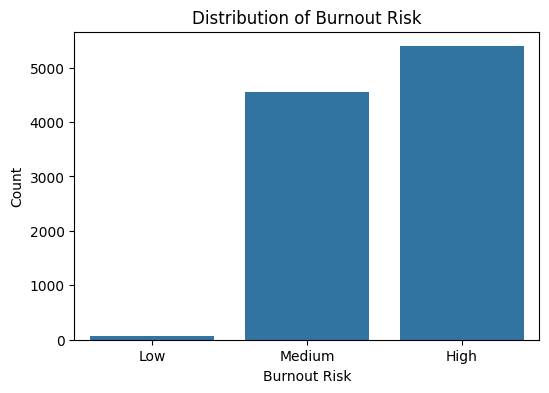

In [ ]:
# 1. 번아웃 위험 분포 확인

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Burnout_Risk',
    order=['Low','Medium','High']
)

plt.title("Distribution of Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Count")

plt.show()

번아웃 위험 수준이 낮은 응답자보다 중·고위험군에 해당하는 응답자가 상대적으로 많음을 의미.

또한 클래스 간 데이터 불균형이 존재하므로, 이후 머신러닝 모델 학습에서는 이러한 특성을 고려하여 모델 성능을 평가할 필요가 있음.

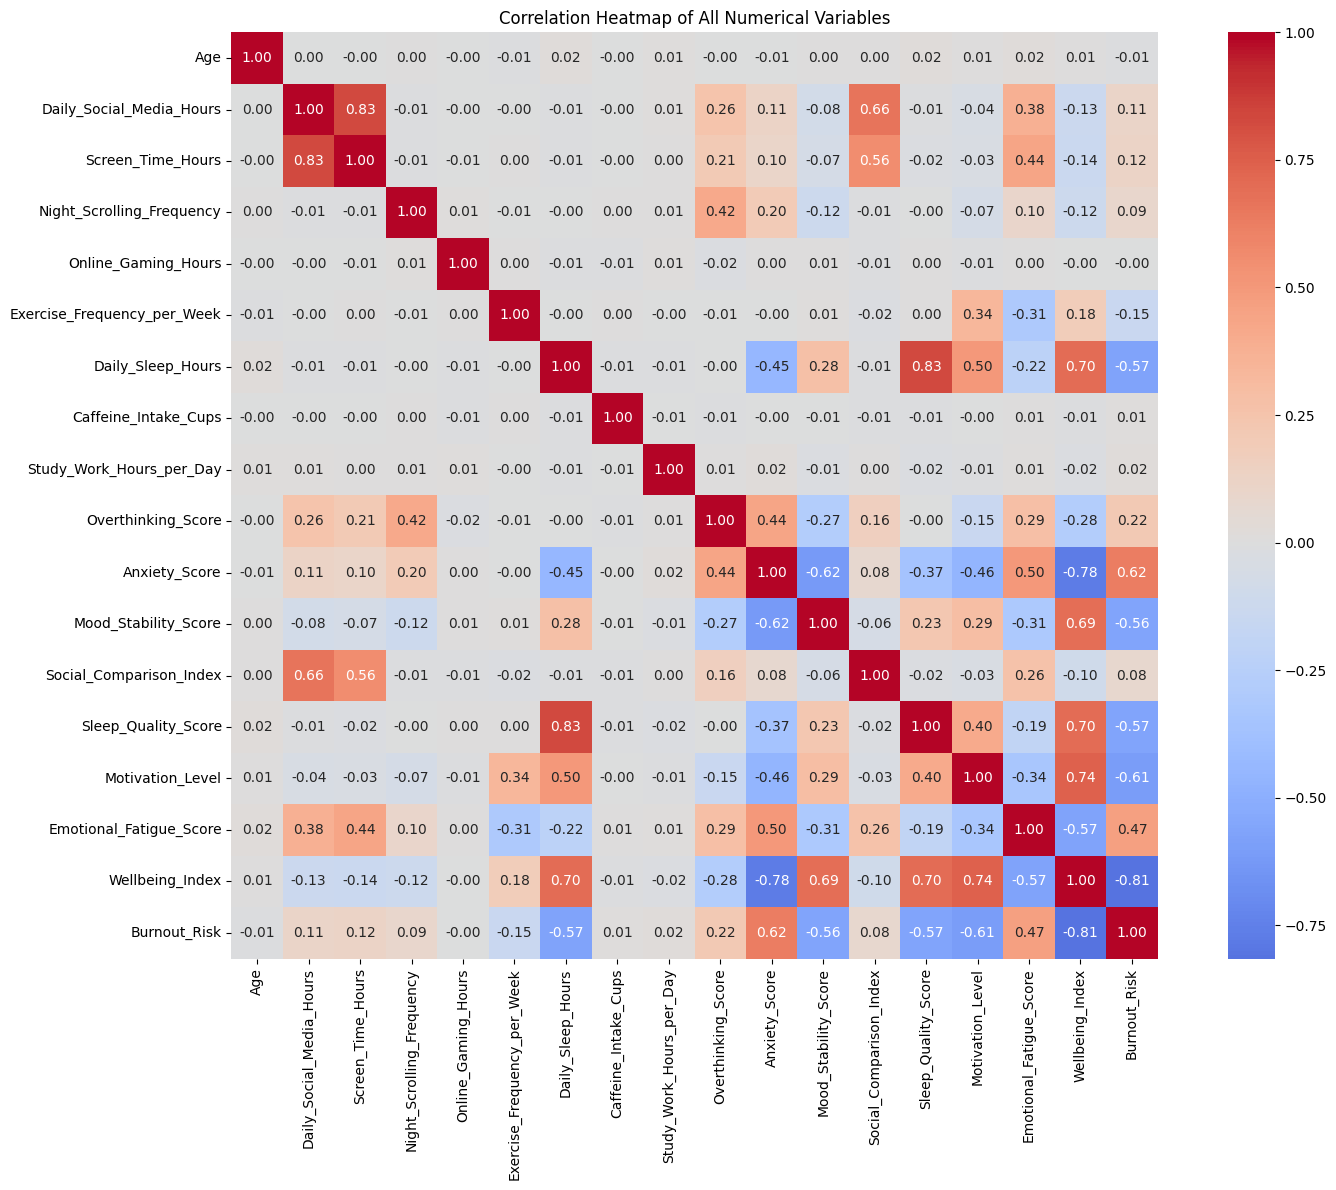

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Burnout Risk를 숫자로 변환
df_corr = df.copy()

df_corr["Burnout_Risk"] = df_corr["Burnout_Risk"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# 숫자형 컬럼만 선택
numeric_df = df_corr.select_dtypes(include='number')

# 상관관계 계산
corr = numeric_df.corr()

# 히트맵
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Heatmap of All Numerical Variables")
plt.tight_layout()
plt.show()

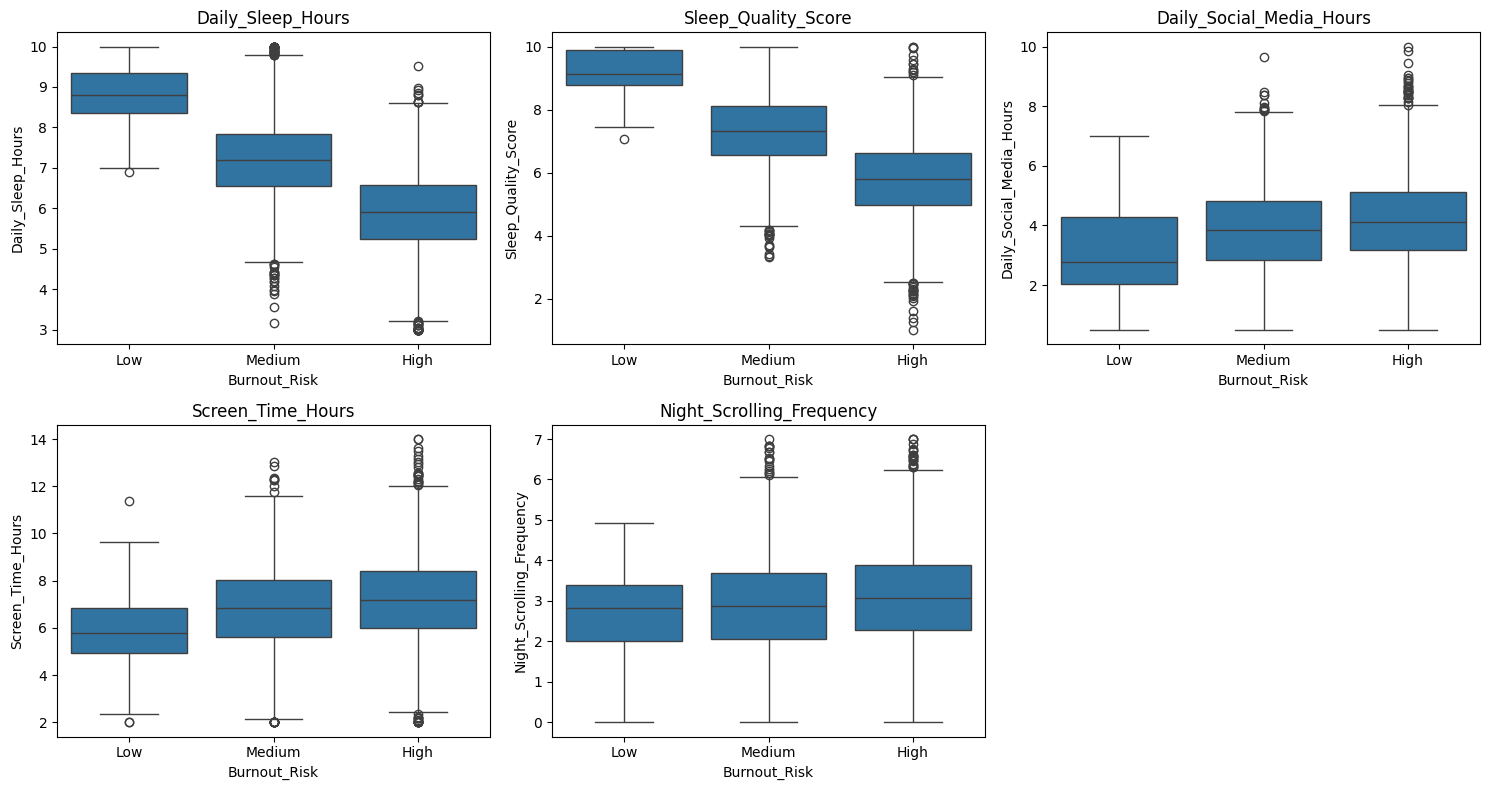

In [ ]:
# 2. 생활습관 & 번아웃

lifestyle_cols = [
    'Daily_Sleep_Hours',
    'Sleep_Quality_Score',
    'Daily_Social_Media_Hours',
    'Screen_Time_Hours',
    'Night_Scrolling_Frequency'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), lifestyle_cols):
    sns.boxplot(
        data=df,
        x='Burnout_Risk',
        y=col,
        order=['Low', 'Medium', 'High'],
        ax=ax
    )
    ax.set_title(col)

# 마지막 빈 칸 제거
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

번아웃 위험이 높아질수록

일일 수면시간(Daily_Sleep_Hours)과 수면의 질(Sleep_Quality_Score)은 감소,

SNS 이용시간(Daily_Social_Media_Hours), 화면 사용시간(Screen_Time_Hours), 야간 스크롤링 빈도(Night_Scrolling_Frequency)는 증가하는 경향

--> 이러한 결과는 건강한 수면 습관은 번아웃 위험을 낮추고, 과도한 디지털 기기 사용은 번아웃 위험 증가와 관련될 가능성을 시사

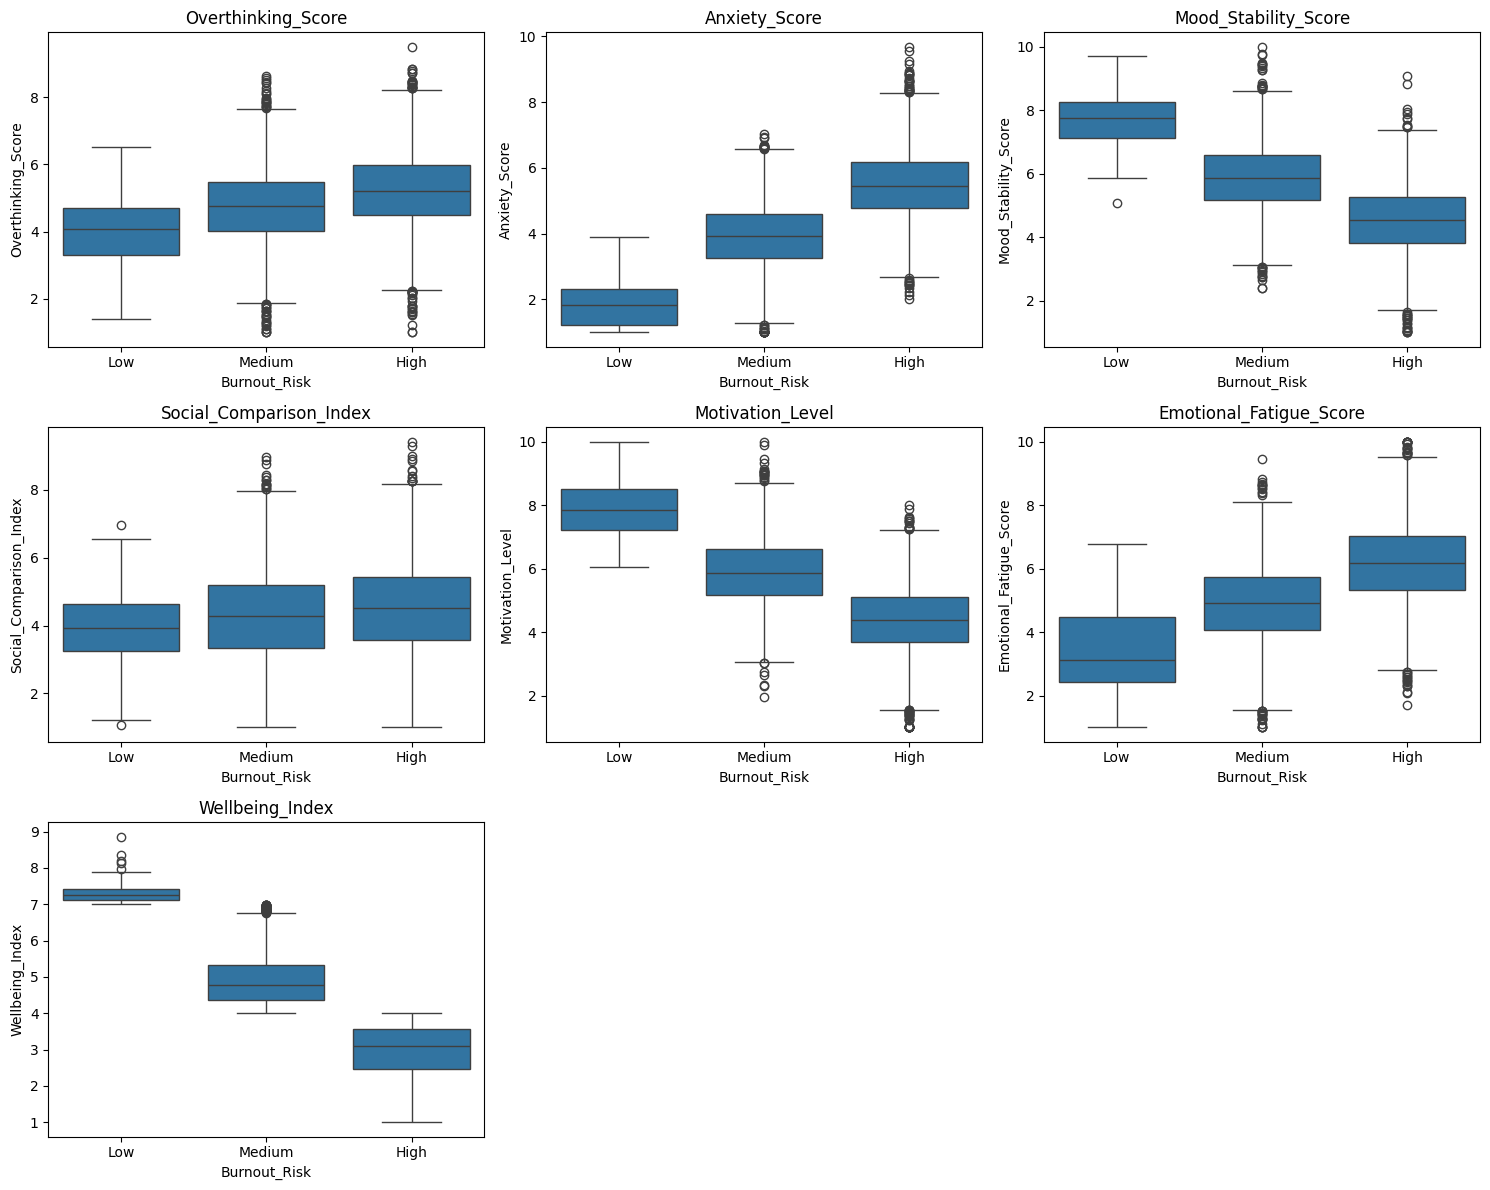

In [ ]:
# 3. 정신건강 & 번아웃

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flatten(), mental_cols):

    sns.boxplot(
        data=df,
        x='Burnout_Risk',
        y=col,
        order=['Low', 'Medium', 'High'],
        ax=ax
    )

    ax.set_title(col)

# 사용하지 않는 subplot 제거
fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()

# **4. 머신러닝_번아웃 예측**


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# 생활습관 변수
features = [
    "Daily_Sleep_Hours",
    "Sleep_Quality_Score",
    "Exercise_Frequency_per_Week",
    "Screen_Time_Hours",
    "Daily_Social_Media_Hours",
    "Night_Scrolling_Frequency"
]

# X, y
X = df[features]
y = df["Burnout_Risk"]

print("사용 변수:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

사용 변수:
['Daily_Sleep_Hours', 'Sleep_Quality_Score', 'Exercise_Frequency_per_Week', 'Screen_Time_Hours', 'Daily_Social_Media_Hours', 'Night_Scrolling_Frequency']

X shape: (10000, 6)
y shape: (10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

# 예측
logistic_pred = logistic_model.predict(X_test_scaled)


# 성능 평가
print("===== Logistic Regression =====")

print(
    "Accuracy :",
    round(accuracy_score(y_test, logistic_pred), 3)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            logistic_pred,
            average="weighted"
        ),
        3
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            logistic_pred,
            average="weighted"
        ),
        3
    )
)

print(
    "F1-score :",
    round(
        f1_score(
            y_test,
            logistic_pred,
            average="weighted"
        ),
        3
    )
)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, logistic_pred))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

===== Logistic Regression =====
Accuracy : 0.775
Precision: 0.776
Recall   : 0.775
F1-score : 0.773

Confusion Matrix
[[869   0 209]
 [  0   1  12]
 [229   0 680]]

Classification Report
              precision    recall  f1-score   support

        High       0.79      0.81      0.80      1078
         Low       1.00      0.08      0.14        13
      Medium       0.75      0.75      0.75       909

    accuracy                           0.78      2000
   macro avg       0.85      0.54      0.56      2000
weighted avg       0.78      0.78      0.77      2000



In [ ]:
# Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

# 예측
rf_pred = rf_model.predict(X_test)


# 성능 평가
print("===== Random Forest Classifier =====")

print(
    "Accuracy :",
    round(accuracy_score(y_test, rf_pred), 3)
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            rf_pred,
            average="weighted"
        ),
        3
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            rf_pred,
            average="weighted"
        ),
        3
    )
)

print(
    "F1-score :",
    round(
        f1_score(
            y_test,
            rf_pred,
            average="weighted"
        ),
        3
    )
)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

===== Random Forest Classifier =====
Accuracy : 0.763
Precision: 0.764
Recall   : 0.763
F1-score : 0.761

Confusion Matrix
[[864   0 214]
 [  0   1  12]
 [247   0 662]]

Classification Report
              precision    recall  f1-score   support

        High       0.78      0.80      0.79      1078
         Low       1.00      0.08      0.14        13
      Medium       0.75      0.73      0.74       909

    accuracy                           0.76      2000
   macro avg       0.84      0.54      0.56      2000
weighted avg       0.76      0.76      0.76      2000



In [ ]:
#Random Forest Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== Random Forest Feature Importance =====")
print(importance)

===== Random Forest Feature Importance =====
                       Feature  Importance
0            Daily_Sleep_Hours    0.293926
1          Sleep_Quality_Score    0.252751
2  Exercise_Frequency_per_Week    0.123923
4     Daily_Social_Media_Hours    0.110692
3            Screen_Time_Hours    0.109570
5    Night_Scrolling_Frequency    0.109139


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, logistic_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, logistic_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
})

comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(3)

print("===== Model Comparison1 =====")
print(comparison)

===== Model Comparison1 =====
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.775      0.776   0.775     0.773
1        Random Forest     0.764      0.764   0.764     0.761


**랜덤포레스트 튜닝 (Optuna / Grid Search)**

In [ ]:
!pip install optuna -q

import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier


# Optuna 목적 함수
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 300
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 20
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),
        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        ),
        "random_state": 42
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )

    return scores.mean()


# Optuna 실행
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)


# 최적 결과
print("===== Best Parameters =====")
print(study.best_params)

print("\nBest CV F1-score :",
      round(study.best_value, 3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 22.7 MB/s eta 0:00:00


[I 2026-08-23 09:24:04,932] A new study created in memory with name: no-name-e71f05e3-7ede-4629-877c-8f189267e6a8
[I 2026-08-23 09:24:14,960] Trial 0 finished with value: 0.7651265021444758 and parameters: {'n_estimators': 176, 'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.7651265021444758.
[I 2026-08-23 09:24:25,436] Trial 1 finished with value: 0.7657098045839271 and parameters: {'n_estimators': 248, 'max_depth': 20, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': None}. Best is trial 1 with value: 0.7657098045839271.
[I 2026-08-23 09:24:30,897] Trial 2 finished with value: 0.767882220989419 and parameters: {'n_estimators': 178, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 2 with value: 0.767882220989419.
[I 2026-08-23 09:24:35,720] Trial 3 finished with value: 0.7

===== Best Parameters =====
{'n_estimators': 297, 'max_depth': 17, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None}

Best CV F1-score : 0.769


In [ ]:
# 최적 하이퍼파라미터로 Random Forest 생성
optimized_rf = RandomForestClassifier(
    **study.best_params
)

# 학습
optimized_rf.fit(
    X_train,
    y_train
)

# 예측
optimized_rf_pred = optimized_rf.predict(X_test)


# 성능 평가
print("\n===== Optimized Random Forest =====")

print(
    "Accuracy :",
    round(
        accuracy_score(y_test, optimized_rf_pred),
        3
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            optimized_rf_pred,
            average="weighted"
        ),
        3
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            optimized_rf_pred,
            average="weighted"
        ),
        3
    )
)

print(
    "F1-score :",
    round(
        f1_score(
            y_test,
            optimized_rf_pred,
            average="weighted"
        ),
        3
    )
)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, optimized_rf_pred))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        optimized_rf_pred,
        zero_division=0
    )
)


===== Optimized Random Forest =====
Accuracy : 0.765
Precision: 0.76
Recall   : 0.765
F1-score : 0.763

Confusion Matrix
[[865   0 213]
 [  0   0  13]
 [243   0 666]]

Classification Report
              precision    recall  f1-score   support

        High       0.78      0.80      0.79      1078
         Low       0.00      0.00      0.00        13
      Medium       0.75      0.73      0.74       909

    accuracy                           0.77      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.76      0.77      0.76      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Random Forest - Grid Search (간소화 버전)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("===== Best Parameters =====")
print(grid_search.best_params_)

print("\n===== Best CV F1-score =====")
print(round(grid_search.best_score_, 3))

Fitting 3 folds for each of 72 candidates, totalling 216 fits
===== Best Parameters =====
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

===== Best CV F1-score =====
0.767


In [ ]:
# 최적 Random Forest
rf_grid = grid_search.best_estimator_

# 테스트 예측
rf_grid_pred = rf_grid.predict(X_test)

# 성능 평가
print("\n===== Random Forest (Grid Search) =====")
print("Accuracy :", round(accuracy_score(y_test, rf_grid_pred), 3))
print("Precision:", round(precision_score(y_test, rf_grid_pred, average="weighted"), 3))
print("Recall   :", round(recall_score(y_test, rf_grid_pred, average="weighted"), 3))
print("F1-score :", round(f1_score(y_test, rf_grid_pred, average="weighted"), 3))


===== Random Forest (Grid Search) =====
Accuracy : 0.77
Precision: 0.765
Recall   : 0.77
F1-score : 0.767


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
comparison_tuned = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest (Baseline)",
        "Random Forest (Optuna)",
        "Random Forest (Grid Search)"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, optimized_rf_pred),
        accuracy_score(y_test, rf_grid_pred)
    ],

    "Precision": [
        precision_score(y_test, logistic_pred, average="weighted", zero_division=0),
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        precision_score(y_test, optimized_rf_pred, average="weighted", zero_division=0),
        precision_score(y_test, rf_grid_pred, average="weighted", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, logistic_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, optimized_rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_grid_pred, average="weighted", zero_division=0)
    ],

    "F1-score": [
        f1_score(y_test, logistic_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, optimized_rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_grid_pred, average="weighted", zero_division=0)
    ]
})

# 소수점 3자리
comparison_tuned.iloc[:, 1:] = comparison_tuned.iloc[:, 1:].round(3)

print("===== Model Comparison2 =====")
print(comparison_tuned)

===== Model Comparison2 =====
                         Model  Accuracy  Precision  Recall  F1-score
0          Logistic Regression     0.775      0.776   0.775     0.773
1     Random Forest (Baseline)     0.764      0.764   0.764     0.761
2       Random Forest (Optuna)     0.766      0.760   0.766     0.763
3  Random Forest (Grid Search)     0.770      0.765   0.770     0.767


**다양한 모델 비교**

In [ ]:
def evaluate_model(model_name, y_test, pred):
    print(f"===== {model_name} =====")

    print("Accuracy :",
          round(accuracy_score(y_test, pred), 3))

    print("Precision:",
          round(precision_score(
              y_test, pred,
              average="weighted",
              zero_division=0
          ), 3))

    print("Recall   :",
          round(recall_score(
              y_test, pred,
              average="weighted",
              zero_division=0
          ), 3))

    print("F1-score :",
          round(f1_score(
              y_test, pred,
              average="weighted",
              zero_division=0
          ), 3))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, pred))

    print("\nClassification Report")
    print(classification_report(
        y_test,
        pred,
        zero_division=0
    ))

In [ ]:
# XGBoost

from xgboost import XGBClassifier

# 문자열 타겟을 숫자로 변환
label_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_train_xgb = y_train.map(label_map)
y_test_xgb = y_test.map(label_map)

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train_xgb
)

xgb_pred = xgb_model.predict(X_test)

evaluate_model(
    "XGBoost",
    y_test_xgb,
    xgb_pred
)

===== XGBoost =====
Accuracy : 0.748
Precision: 0.746
Recall   : 0.748
F1-score : 0.746

Confusion Matrix
[[  1  12   0]
 [  1 656 252]
 [  0 240 838]]

Classification Report
              precision    recall  f1-score   support

           0       0.50      0.08      0.13        13
           1       0.72      0.72      0.72       909
           2       0.77      0.78      0.77      1078

    accuracy                           0.75      2000
   macro avg       0.66      0.53      0.54      2000
weighted avg       0.75      0.75      0.75      2000



In [ ]:
# LightGBM

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm_model.predict(X_test)

evaluate_model(
    "LightGBM",
    y_test,
    lgbm_pred
)

===== LightGBM =====
Accuracy : 0.762
Precision: 0.76
Recall   : 0.762
F1-score : 0.76

Confusion Matrix
[[856   0 222]
 [  0   1  12]
 [241   1 667]]

Classification Report
              precision    recall  f1-score   support

        High       0.78      0.79      0.79      1078
         Low       0.50      0.08      0.13        13
      Medium       0.74      0.73      0.74       909

    accuracy                           0.76      2000
   macro avg       0.67      0.53      0.55      2000
weighted avg       0.76      0.76      0.76      2000



In [ ]:
# SVM

from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_pred = svm_model.predict(X_test_scaled)

evaluate_model(
    "SVM",
    y_test,
    svm_pred
)

===== SVM =====
Accuracy : 0.77
Precision: 0.765
Recall   : 0.77
F1-score : 0.767

Confusion Matrix
[[883   0 195]
 [  0   0  13]
 [251   0 658]]

Classification Report
              precision    recall  f1-score   support

        High       0.78      0.82      0.80      1078
         Low       0.00      0.00      0.00        13
      Medium       0.76      0.72      0.74       909

    accuracy                           0.77      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.77      0.77      0.77      2000



In [ ]:
# MLP

from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlp_model.fit(
    X_train_scaled,
    y_train
)

mlp_pred = mlp_model.predict(X_test_scaled)

evaluate_model(
    "MLP",
    y_test,
    mlp_pred
)

===== MLP =====
Accuracy : 0.768
Precision: 0.769
Recall   : 0.768
F1-score : 0.766

Confusion Matrix
[[867   0 211]
 [  0   1  12]
 [241   0 668]]

Classification Report
              precision    recall  f1-score   support

        High       0.78      0.80      0.79      1078
         Low       1.00      0.08      0.14        13
      Medium       0.75      0.73      0.74       909

    accuracy                           0.77      2000
   macro avg       0.84      0.54      0.56      2000
weighted avg       0.77      0.77      0.77      2000



In [ ]:
# CatBoost

!pip install catboost
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100,
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train,
    y_train
)

cat_pred = cat_model.predict(X_test)

# CatBoost 결과가 (n, 1) 형태일 수 있어서 1차원으로 변환
cat_pred = cat_pred.ravel()

evaluate_model(
    "CatBoost",
    y_test,
    cat_pred
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
===== CatBoost =====
Accuracy : 0.754
Precision: 0.752
Recall   : 0.754
F1-score : 0.752

Confusion Matrix
[[854   0 224]
 [  0   1  12]
 [255   1 653]]

Classification Report
              precision    recall  f1-score   support

        High       0.77      0.79      0.78      1078
         Low       0.50      0.08      0.13        13
      Medium       0.73      0.72      0.73       909

    accuracy                           0.75      2000
   macro avg       0.67      0.53      0.55      2000
weighted avg       0.75      0.75      0.75      2000



In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "SVM",
        "MLP",
        "CatBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test_xgb, xgb_pred),
        accuracy_score(y_test, lgbm_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, mlp_pred),
        accuracy_score(y_test, cat_pred)
    ],

    "Precision": [
        precision_score(y_test, logistic_pred, average="weighted", zero_division=0),
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        precision_score(y_test_xgb, xgb_pred, average="weighted", zero_division=0),
        precision_score(y_test, lgbm_pred, average="weighted", zero_division=0),
        precision_score(y_test, svm_pred, average="weighted", zero_division=0),
        precision_score(y_test, mlp_pred, average="weighted", zero_division=0),
        precision_score(y_test, cat_pred, average="weighted", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, logistic_pred, average="weighted", zero_division=0),
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test_xgb, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, lgbm_pred, average="weighted", zero_division=0),
        recall_score(y_test, svm_pred, average="weighted", zero_division=0),
        recall_score(y_test, mlp_pred, average="weighted", zero_division=0),
        recall_score(y_test, cat_pred, average="weighted", zero_division=0)
    ],

    "F1-score": [
        f1_score(y_test, logistic_pred, average="weighted", zero_division=0),
        f1_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test_xgb, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, lgbm_pred, average="weighted", zero_division=0),
        f1_score(y_test, svm_pred, average="weighted", zero_division=0),
        f1_score(y_test, mlp_pred, average="weighted", zero_division=0),
        f1_score(y_test, cat_pred, average="weighted", zero_division=0)
    ]
})

model_comparison.iloc[:, 1:] = model_comparison.iloc[:, 1:].round(3)

model_comparison = model_comparison.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

print("===== Model Comparison3 =====")
print(model_comparison)

===== Model Comparison3 =====
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.775      0.776   0.775     0.773
1                  SVM     0.770      0.765   0.770     0.767
2                  MLP     0.768      0.769   0.768     0.766
3        Random Forest     0.764      0.764   0.764     0.761
4             LightGBM     0.762      0.760   0.762     0.760
5             CatBoost     0.754      0.752   0.754     0.752
6              XGBoost     0.748      0.746   0.748     0.746


**SVM 튜닝**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# SVM Grid Search
# ==========================================

svm = SVC()

svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print("===== Best SVM Parameters =====")
print(svm_grid.best_params_)

print("\n===== Best CV F1-score =====")
print(round(svm_grid.best_score_, 3))

# 최적 모델
best_svm = svm_grid.best_estimator_

# 테스트 예측
y_pred_svm = best_svm.predict(X_test_scaled)

print("\n===== SVM (Grid Search) =====")
print("Accuracy :", round(accuracy_score(y_test, y_pred_svm), 3))
print("Precision:", round(precision_score(y_test, y_pred_svm, average='weighted'), 3))
print("Recall   :", round(recall_score(y_test, y_pred_svm, average='weighted'), 3))
print("F1-score :", round(f1_score(y_test, y_pred_svm, average='weighted'), 3))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
===== Best SVM Parameters =====
{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}

===== Best CV F1-score =====
0.772

===== SVM (Grid Search) =====
Accuracy : 0.775
Precision: 0.77
Recall   : 0.775
F1-score : 0.773


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("===== Model F1 Comparison =====")
print("Logistic F1:", f1_score(
    y_test, logistic_pred,
    average='weighted'
))
print("SVM F1:", f1_score(
    y_test, y_pred_svm,
    average='weighted'
))

print("\n===== Model Accuracy Comparison =====")
print("Logistic Accuracy:", accuracy_score(y_test, logistic_pred))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

===== Model F1 Comparison =====
Logistic F1: 0.77293776768304
SVM F1: 0.7725432169957255

===== Model Accuracy Comparison =====
Logistic Accuracy: 0.775
SVM Accuracy: 0.7755


# **5. XAI(Explainable AI)**

: 머신러닝 모델의 예측 결과가 왜 그렇게 나왔는지 설명해주는 기법.

모델의 예측에 각 변수가 얼마나 영향을 주었는지 확인하여 모델의 해석 가능성을 높일 수 있다.

**SHAP**

: SHAP는 각 변수의 기여도를 계산하여 예측 결과에 어떤 영향을 주었는지 설명하는 XAI 기법.

In [ ]:
!pip install shap -q

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 최종 Logistic Regression 확인

features = [
    "Daily_Sleep_Hours",
    "Sleep_Quality_Score",
    "Exercise_Frequency_per_Week",
    "Screen_Time_Hours",
    "Daily_Social_Media_Hours",
    "Night_Scrolling_Frequency"
]

X = df[features]
y = df["Burnout_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Logistic Regression Coefficient

coefficient = pd.DataFrame(
    logistic_model.coef_,
    columns=X.columns,
    index=logistic_model.classes_
)

print("===== Logistic Regression Coefficients =====")
print(coefficient.round(3))

===== Logistic Regression Coefficients =====
        Daily_Sleep_Hours  Sleep_Quality_Score  Exercise_Frequency_per_Week  \
High               -1.100               -1.106                       -0.459   
Low                 1.159                1.215                        0.438   
Medium             -0.060               -0.109                        0.022   

        Screen_Time_Hours  Daily_Social_Media_Hours  Night_Scrolling_Frequency  
High                0.143                     0.376                      0.344  
Low                -0.122                    -0.533                     -0.393  
Medium             -0.021                     0.157                      0.050  


In [ ]:
# 전체적 변수 영향

coef_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.mean(
        np.abs(logistic_model.coef_),
        axis=0
    )
})

coef_importance = coef_importance.sort_values(
    by="Importance",
    ascending=False
)

print("===== Overall Feature Importance =====")
print(coef_importance.round(3))

===== Overall Feature Importance =====
                       Feature  Importance
1          Sleep_Quality_Score       0.810
0            Daily_Sleep_Hours       0.773
4     Daily_Social_Media_Hours       0.355
2  Exercise_Frequency_per_Week       0.306
5    Night_Scrolling_Frequency       0.262
3            Screen_Time_Hours       0.095


In [ ]:
# Linear SHAP Explainer
explainer = shap.LinearExplainer(
    logistic_model,
    X_train_scaled
)

shap_values = explainer(
    X_test_scaled
)

print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(2000, 6, 3)


In [ ]:
# 전체적인 SHAP Feature Importance

shap_array = shap_values.values

# 다중분류: (samples, features, classes)
if shap_array.ndim == 3:

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=(0, 2)
    )

else:

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=0
    )

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP|": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

print("===== SHAP Feature Importance =====")
print(shap_importance.round(3))

===== SHAP Feature Importance =====
                       Feature  Mean |SHAP|
1          Sleep_Quality_Score        0.633
0            Daily_Sleep_Hours        0.618
4     Daily_Social_Media_Hours        0.284
2  Exercise_Frequency_per_Week        0.242
5    Night_Scrolling_Frequency        0.215
3            Screen_Time_Hours        0.076


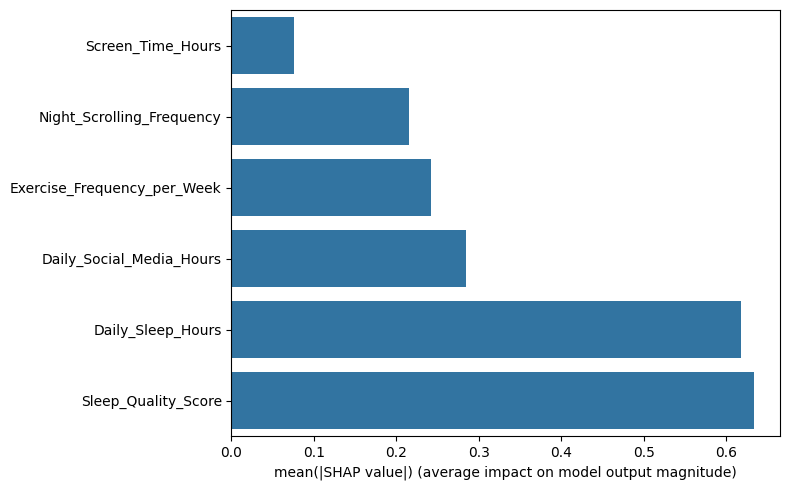

In [ ]:
# SHAP Feature Importance 시각화

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# SHAP 값에서 전체 변수 중요도 계산
shap_array = shap_values.values

# (samples, features, classes) 형태인 경우
if shap_array.ndim == 3:
    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=(0, 2)
    )
else:
    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=0
    )

# 데이터프레임 생성
shap_importance = pd.DataFrame({
    'Feature': X.columns,
    'Mean_SHAP': mean_abs_shap
})

# 중요도가 높은 변수가 위로 오도록 정렬
shap_importance = shap_importance.sort_values(
    'Mean_SHAP',
    ascending=True
)

# 그래프
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shap_importance,
    x='Mean_SHAP',
    y='Feature'
)

plt.xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
plt.ylabel('')

# 제목 제거
plt.title('')

plt.tight_layout()
plt.show()

In [ ]:
# SHAP Summary Plot

class_names = logistic_model.classes_

print("Classes:", class_names)

Classes: ['High' 'Low' 'Medium']


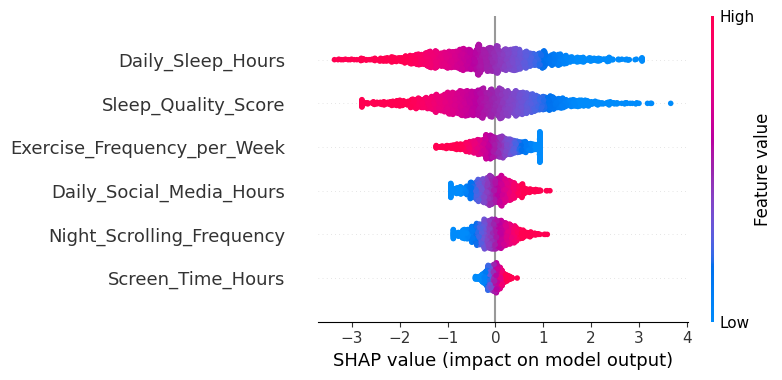

In [ ]:
high_idx = list(class_names).index("High")

high_shap = shap_values[:, :, high_idx]

shap.summary_plot(
    high_shap,
    X_test,
    feature_names=X.columns
)

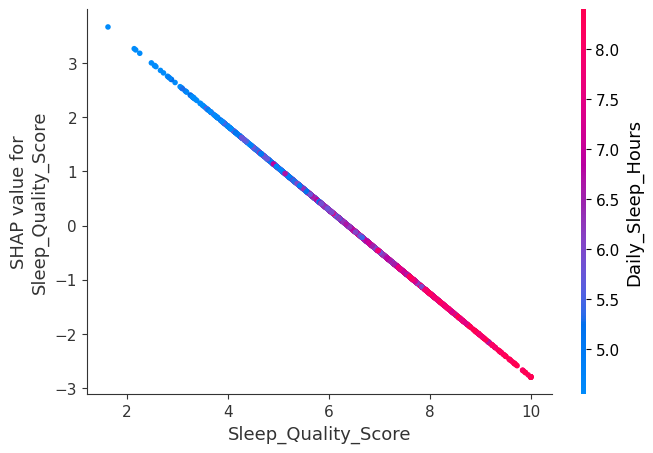

<Figure size 640x480 with 0 Axes>

In [ ]:
# ==========================================
# SHAP Dependence Plot
# High Burnout Risk
# ==========================================

import shap
import matplotlib.pyplot as plt

# High 클래스의 SHAP 값
high_shap = shap_values.values[:, :, 0]

# Dependence Plot
shap.dependence_plot(
    'Sleep_Quality_Score',
    high_shap,
    X_test,
    feature_names=X.columns
)

plt.tight_layout()
plt.show()

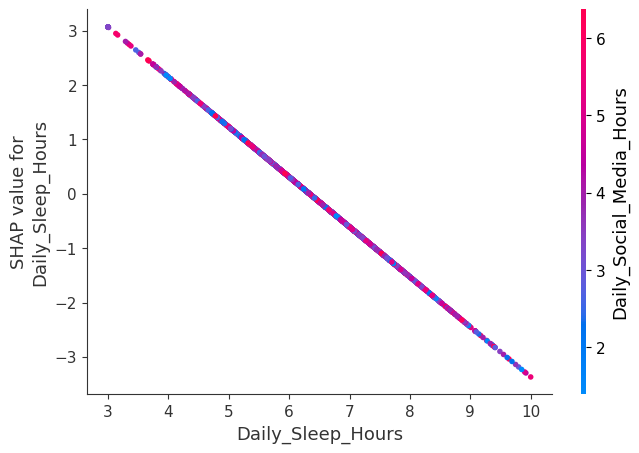

<Figure size 640x480 with 0 Axes>

In [ ]:
# Daily Sleep Hours

shap.dependence_plot(
    'Daily_Sleep_Hours',
    high_shap,
    X_test,
    feature_names=X.columns
)

plt.tight_layout()
plt.show()

In [ ]:
# High 클래스의 위치 확인
class_names = logistic_model.classes_
high_idx = list(class_names).index("High")

# 테스트 데이터의 예측 확률
pred_proba = logistic_model.predict_proba(X_test_scaled)

# High 확률이 가장 높은 샘플
sample_idx = np.argmax(pred_proba[:, high_idx])

print("Sample index:", sample_idx)
print("Actual:", y_test.iloc[sample_idx])
print("Predicted:", logistic_model.predict(X_test_scaled)[sample_idx])
print("High probability:", round(pred_proba[sample_idx, high_idx], 3))

Sample index: 1196
Actual: High
Predicted: High
High probability: 0.999


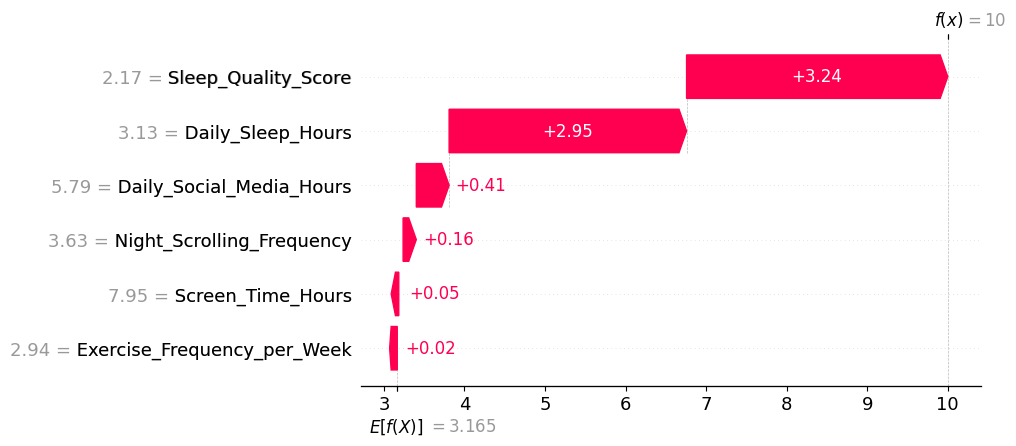

In [ ]:
# High 클래스에 대한 SHAP 값
# 실제 변수명을 포함한 SHAP Explanation 생성

waterfall_data = shap.Explanation(
    values=high_shap[sample_idx],
    base_values=explainer.expected_value[0],
    data=X_test.iloc[sample_idx].values,
    feature_names=X.columns.tolist()
)

# Waterfall Plot
shap.plots.waterfall(
    waterfall_data,
    max_display=6
)